## create local automata

In [63]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

def creare_random_connected_graph(n_nodes, n_edges):
    # Generate a random graph
    G = nx.Graph()

    # Add nodes
    G.add_nodes_from(range(n_nodes))

    # Add random edges
    while G.number_of_edges() < n_edges:
        u = random.randint(0, n_nodes-1)
        v = random.randint(0, n_nodes-1)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
    # Check if graph is connected
    while not nx.is_connected(G):
        # Add random edges until connected
        # get disconnected node
        disconnected_node = random.choice(list(nx.isolates(G)))
        # get random node
        random_node = random.choice(list(G.nodes()))
        if disconnected_node != random_node and not G.has_edge(disconnected_node, random_node):
            G.add_edge(disconnected_node, random_node)
    return G


colors = [np.random.rand(3,) for _ in range(5)]
graphs = []
pos_list = []
graphs_number = 5
nodes_number = 5
edges_number = 7

for _ in range(graphs_number):
    G = creare_random_connected_graph(nodes_number, edges_number)
    graphs.append(G)
    pos_list.append(nx.spring_layout(G))

## prepare states

In [89]:
numbers = np.random.randint(0, nodes_number, size=nodes_number)
target_automaton = 0
target_state = 0

states = []
for i in range(graphs_number):
    states.append({'goal': {'target_automaton': (target_automaton+i)%graphs_number, 'target_state': (target_state+i)%graphs_number},
                   'local_states': numbers, 'shortest_path': [], 'edge_conditions':{}, 'current_edge':None})
len(states)
states

[{'goal': {'target_automaton': 0, 'target_state': 0},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [],
  'edge_conditions': {},
  'current_edge': None},
 {'goal': {'target_automaton': 1, 'target_state': 1},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [],
  'edge_conditions': {},
  'current_edge': None},
 {'goal': {'target_automaton': 2, 'target_state': 2},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [],
  'edge_conditions': {},
  'current_edge': None},
 {'goal': {'target_automaton': 3, 'target_state': 3},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [],
  'edge_conditions': {},
  'current_edge': None},
 {'goal': {'target_automaton': 4, 'target_state': 4},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [],
  'edge_conditions': {},
  'current_edge': None}]

In [90]:
# Compute shortest path
for i in range(graphs_number):
    state = states[i]
    current_goal = state['goal']
    target_state = current_goal['target_state']
    target_automaton = current_goal['target_automaton']
    local_state = numbers[i]

    G = graphs[i]

    current_shortest_path = nx.shortest_path(G, source=local_state, target=target_state)
    print("Shortest path:", current_shortest_path)

    states[i]['shortest_path'] = current_shortest_path

Shortest path: [1, 0]
Shortest path: [2, 1]
Shortest path: [3, 2]
Shortest path: [2, 3]
Shortest path: [0, 2, 4]


## animate

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


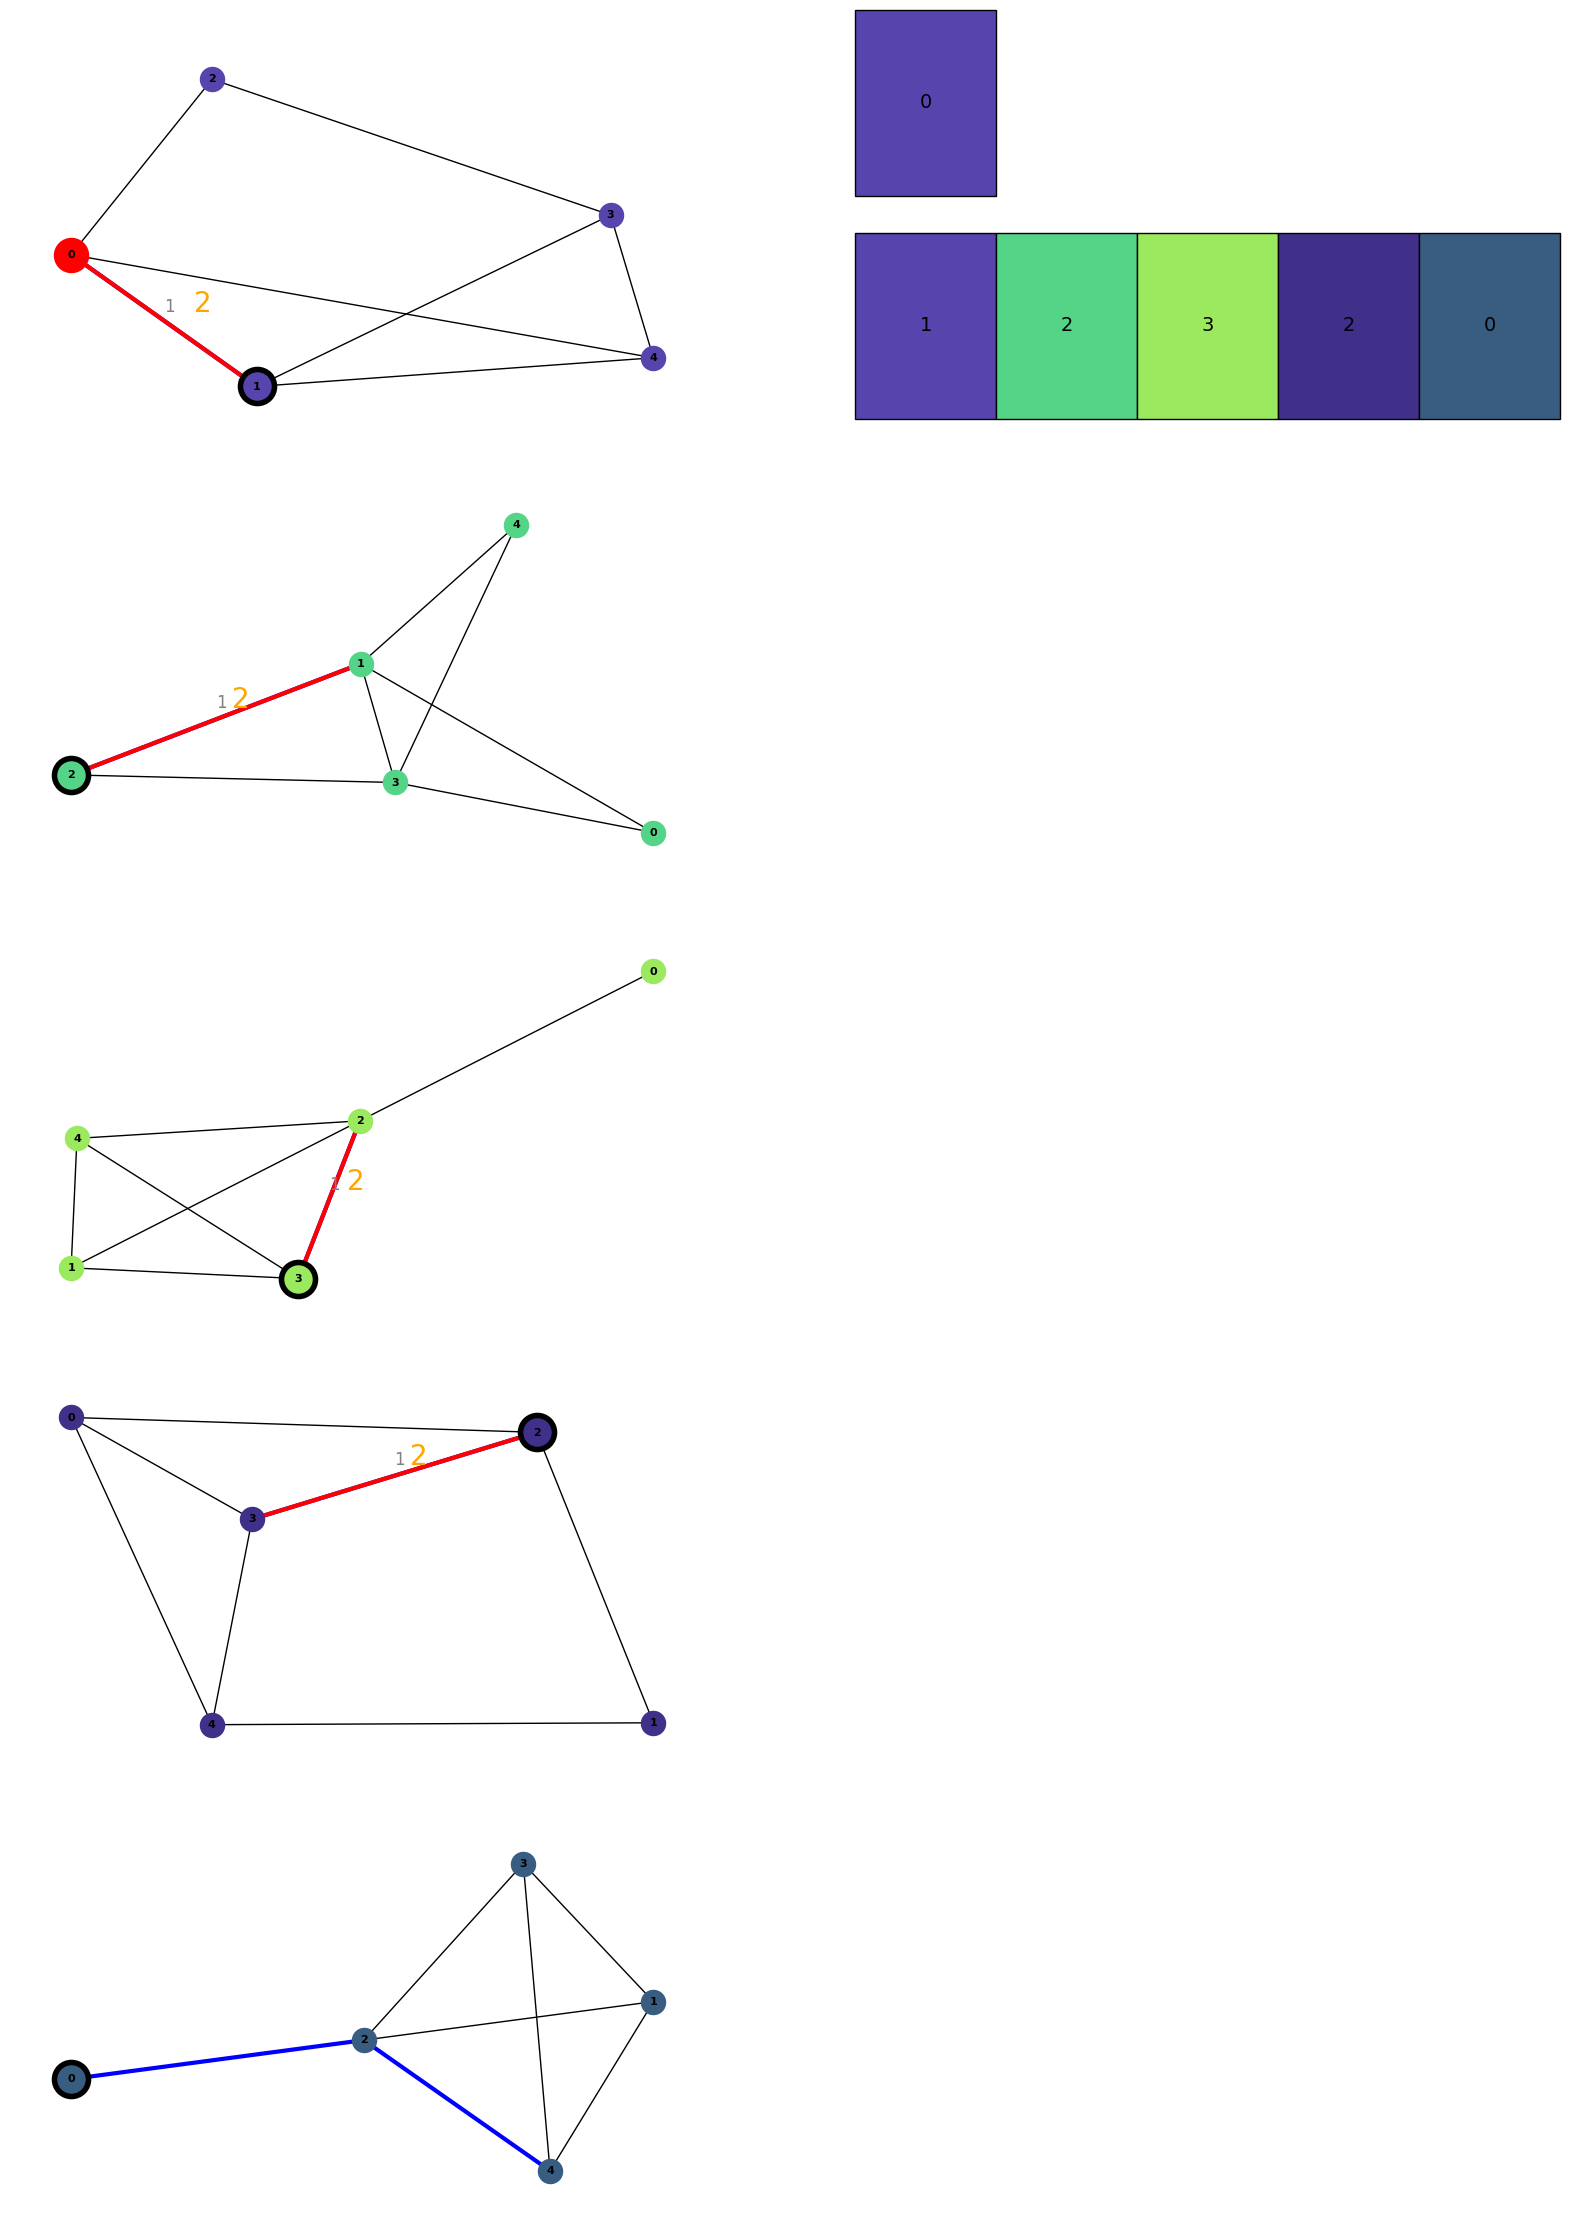

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with custom gridspec
fig = plt.figure(figsize=(20, 28))
gs = plt.GridSpec(graphs_number, 2, figure=fig)


# Main automaton data
original_state = states[0]
original_goal = original_state['goal']
original_target_state = original_goal['target_state']
original_automaton = original_goal['target_automaton']


# Function to update the frame
def update(frame,states):
    state = states[frame]
    current_goal = state['goal']
    target_state = current_goal['target_state']
    target_automaton = current_goal['target_automaton']

    numbers = state['local_states']

    # Clear the figure
    fig.clear()
    # Create 5 random graphs in the first column
    for i in range(graphs_number):
        local_state = numbers[i]
        current_state = states[i]
        current_edge = current_state['current_edge']
        
        ax = fig.add_subplot(gs[i, 0])
        # Generate random graph
        G = graphs[i]
        
        # Draw the graph
        pos = pos_list[i]
        
        # Draw all nodes
        nx.draw(G, pos, ax=ax, with_labels=True,
                node_color=colors[i], node_size=300,
                font_size=8, font_weight='bold')
        
        # Highlight the node corresponding to local_state with thicker border
        nx.draw_networkx_nodes(G, pos, ax=ax,
                            nodelist=[local_state],
                            node_color=colors[i],
                            node_size=600,
                            edgecolors='black',
                            linewidths=4)

        # Color the original target state in red
        if i == 0:
            nx.draw_networkx_nodes(G, pos, ax=ax,
                                nodelist=[original_target_state],
                                node_color='red',
                                node_size=600)

        # Highlight the shortest path
        for n in range(len(states[i]['shortest_path'])-1):
            nx.draw_networkx_edges(G, pos, ax=ax,
                                edgelist=[(current_state['shortest_path'][n], current_state['shortest_path'][n+1])],
                                edge_color='blue',
                                width=3)

        # Add current edge to states if edge exists between local state and target state
        if i == target_automaton and G.has_edge(local_state, target_state):
            states[frame]['current_edge'] = (local_state, target_state)
            current_edge = current_state['current_edge']

        # Highlight the current traversing edge
        if current_edge != None:
            nx.draw_networkx_edges(G, pos, ax=ax,
                                    edgelist=[(current_edge[0], current_edge[1])],
                                    edge_color="red",
                                    width=3)

            # Add the colored numbers separately
            # Get the edge midpoint position
            edge_pos = pos[current_edge[0]] + (pos[current_edge[1]] - pos[current_edge[0]]) * 0.5
            plt.text(edge_pos[0], edge_pos[1]+0.05, '1', color='grey', fontsize=12)
            plt.text(edge_pos[0]+0.05, edge_pos[1]+0.05, '2', color='orange', fontsize=20)
        


        #ax.set_title(f'Random Graph {i+1}')

    # Create 1 subplot spanning all rows in second column
    ax = fig.add_subplot(gs[:1, 1])

    ax.clear()
    ax.axis('off')
    # Create vector of 5 random numbers
    top_row = [str(target_state)]
    top_colors = [colors[target_automaton]]
    # Create sample data for tables
    table1 = ax.table(cellText=[numbers],
                    cellColours=[colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 0.5])

    table2 = ax.table(cellText=[top_row],
                    cellColours=[top_colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0.2*target_automaton, 0.6, 0.2, 0.5]) # prvni souradnice ovlivnuje umisteni vrchni bunky

    # Style the tables
    table1.set_fontsize(14)
    table2.set_fontsize(14)

# Create animation
anim = animation.FuncAnimation(fig, update, frames=5,
                               fargs=(states,) ,
                             interval=1000, repeat=True)
anim.save('search_animation.gif', writer='pillow')



In [92]:
states

[{'goal': {'target_automaton': 0, 'target_state': 0},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [1, 0],
  'edge_conditions': {},
  'current_edge': (1, 0)},
 {'goal': {'target_automaton': 1, 'target_state': 1},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [2, 1],
  'edge_conditions': {},
  'current_edge': (2, 1)},
 {'goal': {'target_automaton': 2, 'target_state': 2},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [3, 2],
  'edge_conditions': {},
  'current_edge': (3, 2)},
 {'goal': {'target_automaton': 3, 'target_state': 3},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [2, 3],
  'edge_conditions': {},
  'current_edge': (2, 3)},
 {'goal': {'target_automaton': 4, 'target_state': 4},
  'local_states': array([1, 2, 3, 2, 0]),
  'shortest_path': [0, 2, 4],
  'edge_conditions': {},
  'current_edge': None}]

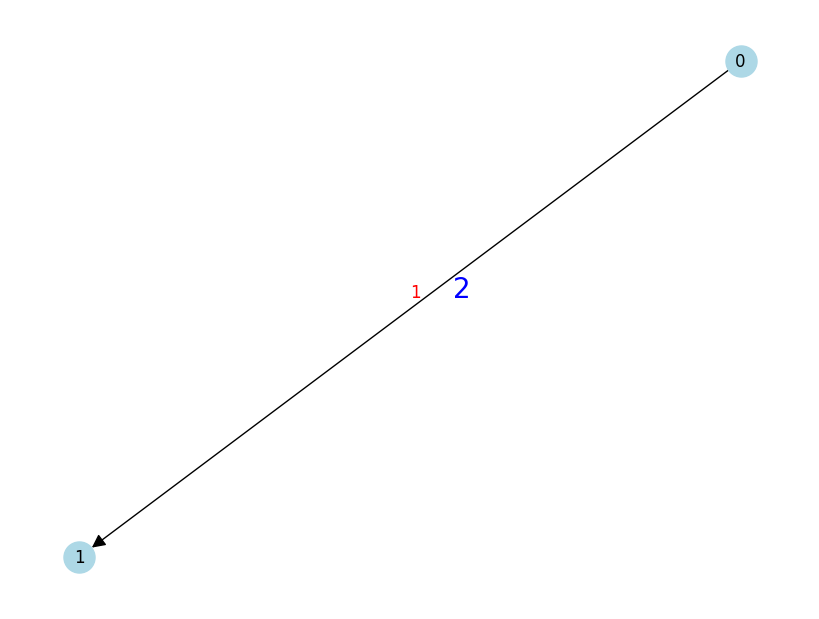

In [24]:
# Create a new figure
plt.figure(figsize=(8,6))

# Create a directed graph
G = nx.DiGraph()
G.add_edge(0, 1)

# Set up the layout
pos = nx.spring_layout(G)

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)

# Create edge labels with different colors
edge_labels = {(0,1): ''}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Add the colored numbers separately
# Get the edge midpoint position
edge_pos = pos[0] + (pos[1] - pos[0]) * 0.5
plt.text(edge_pos[0], edge_pos[1]+0.05, '1', color='red', fontsize=12)
plt.text(edge_pos[0]+0.05, edge_pos[1]+0.05, '2', color='blue', fontsize=20)

plt.axis('off')
plt.show()
